# A/B-тест нового алгоритма рекомендаций

## tl;dr

Эксперимент проводился с 26 июня по 2 июля 2026 года. Контроль — группа 1, новый алгоритм — группа 2.

Глобальный CTR изменился с **0.2087** до **0.2093**, то есть примерно на **+0.28% относительно контроля**. При этом ни один из шести способов сравнения не обнаружил статистически значимого эффекта (`p-value > 0.05`), а 95% bootstrap-интервал разницы включает ноль.

**Рекомендация:** не раскатывать алгоритм на всех пользователей. Сначала проверить фактическое применение алгоритма и логирование, затем при необходимости повторить эксперимент с заранее рассчитанными MDE и размером выборки.

## Context & Methods

Основная гипотеза: новый алгоритм в группе 2 увеличивает CTR по сравнению с контрольной группой 1.

Используем:

1. Welch t-test пользовательского CTR;
2. Mann–Whitney U test;
3. Welch t-test сглаженного CTR при `alpha = 5`;
4. Пуассоновский bootstrap глобального CTR;
5. Welch t-test бакетного CTR;
6. Mann–Whitney U test бакетного CTR.

### Key Assumptions

- пользователь закреплён только за одной экспериментальной группой;
- события за период эксперимента зарегистрированы корректно;
- единица анализа для пользовательских тестов — пользователь;
- порог статистической значимости: `0.05`;
- отсутствие значимости не доказывает полную эквивалентность групп, но не даёт оснований заявлять об улучшении.

## Data

### 1. Импорт библиотек и подключение

In [1]:
import os
from getpass import getpass

import numpy as np
import pandas as pd
import pandahouse
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

sns.set(rc={"figure.figsize": (12, 7)}, style="whitegrid")

clickhouse_password = os.getenv("CLICKHOUSE_PASSWORD")
if clickhouse_password is None:
    clickhouse_password = getpass("Пароль ClickHouse: ")

connection = {
    "host": "http://clickhouse.lab.karpov.courses:8123",
    "password": clickhouse_password,
    "user": "student",
    "database": "simulator_20260620",
}

### 2. Выгрузка данных на уровне пользователя

In [2]:
query = '''
SELECT
    exp_group,
    user_id,
    sum(action = 'like') AS likes,
    sum(action = 'view') AS views,
    likes / views AS ctr
FROM simulator_20260620.feed_actions
WHERE toDate(time) BETWEEN '2026-06-26' AND '2026-07-02'
  AND exp_group IN (1, 2)
GROUP BY
    exp_group,
    user_id
'''

df = pandahouse.read_clickhouse(query, connection=connection)
df.head()

,exp_group,user_id,likes,views,ctr
0,1,109963,4,14,0.285714
1,1,138232,14,61,0.229508
2,1,49204,36,147,0.244898
3,1,49286,2,18,0.111111
4,2,165657,1,12,0.083333


### 3. Проверка данных и базовых метрик

In [3]:
data_quality = pd.DataFrame({
    "rows": [len(df)],
    "missing_values": [int(df.isna().sum().sum())],
    "duplicate_user_group_pairs": [
        int(df.duplicated(["exp_group", "user_id"]).sum())
    ],
})
data_quality

,rows,missing_values,duplicate_user_group_pairs
0,31220,0,0


In [4]:
summary = (
    df.groupby("exp_group")
      .agg(
          users=("user_id", "nunique"),
          likes=("likes", "sum"),
          views=("views", "sum"),
          mean_user_ctr=("ctr", "mean"),
          median_user_ctr=("ctr", "median"),
      )
)

summary["global_ctr"] = summary["likes"] / summary["views"]
summary

,users,likes,views,mean_user_ctr,median_user_ctr,global_ctr
exp_group,,,,,,
1,15620,188894,904995,0.216560,0.202600,0.208724
2,15600,190061,908018,0.216873,0.204082,0.209314


In [5]:
global_ctr_1 = summary.loc[1, "global_ctr"]
global_ctr_2 = summary.loc[2, "global_ctr"]
absolute_effect = global_ctr_2 - global_ctr_1
relative_effect = global_ctr_2 / global_ctr_1 - 1

pd.DataFrame({
    "metric": [
        "Глобальный CTR контроля",
        "Глобальный CTR теста",
        "Абсолютная разница",
        "Относительная разница",
    ],
    "value": [
        global_ctr_1,
        global_ctr_2,
        absolute_effect,
        relative_effect,
    ],
})

,metric,value
0,Глобальный CTR контроля,0.208724
1,Глобальный CTR теста,0.209314
2,Абсолютная разница,0.000590
3,Относительная разница,0.002828


## Results

### 4. Сравнение распределений глазами

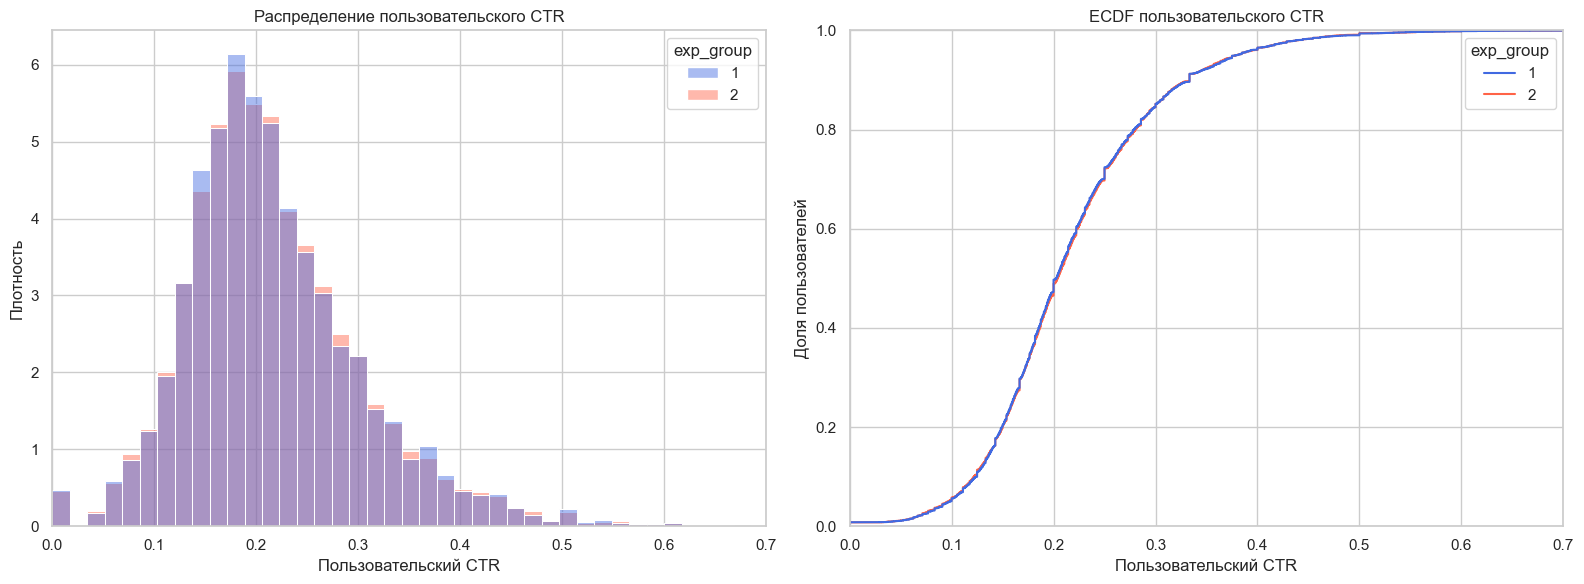

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    data=df,
    x="ctr",
    hue="exp_group",
    bins=50,
    stat="density",
    common_norm=False,
    palette={1: "royalblue", 2: "tomato"},
    alpha=0.45,
    ax=axes[0],
)
axes[0].set(
    title="Распределение пользовательского CTR",
    xlabel="Пользовательский CTR",
    ylabel="Плотность",
    xlim=(0, 0.7),
)

sns.ecdfplot(
    data=df,
    x="ctr",
    hue="exp_group",
    palette={1: "royalblue", 2: "tomato"},
    ax=axes[1],
)
axes[1].set(
    title="ECDF пользовательского CTR",
    xlabel="Пользовательский CTR",
    ylabel="Доля пользователей",
    xlim=(0, 0.7),
)

plt.tight_layout()
plt.show()

Распределения практически накладываются друг на друга. Визуально нет признаков заметного сдвига пользовательского CTR во второй группе.

### 5. Welch t-test и Mann–Whitney U test

In [7]:
ctr_group_1 = df.loc[df["exp_group"] == 1, "ctr"]
ctr_group_2 = df.loc[df["exp_group"] == 2, "ctr"]

raw_ttest = stats.ttest_ind(
    ctr_group_1,
    ctr_group_2,
    equal_var=False,
)

raw_mannwhitney = stats.mannwhitneyu(
    ctr_group_1,
    ctr_group_2,
    alternative="two-sided",
)

pd.DataFrame({
    "test": ["Welch t-test", "Mann–Whitney U"],
    "statistic": [raw_ttest.statistic, raw_mannwhitney.statistic],
    "p_value": [raw_ttest.pvalue, raw_mannwhitney.pvalue],
})

,test,statistic,p_value
0,Welch t-test,-3.152694e-01,0.752559
1,Mann–Whitney U,1.212618e+08,0.470811


Оба теста дают `p-value > 0.05`. Welch t-test не обнаруживает различий средних пользовательских CTR, а Mann–Whitney U test — систематического сдвига распределений.

### 6. Сглаженный CTR при alpha = 5

In [8]:
alpha = 5

global_ctr_by_group = (
    df.groupby("exp_group")["likes"].sum()
    / df.groupby("exp_group")["views"].sum()
)

df["group_global_ctr"] = df["exp_group"].map(global_ctr_by_group)
df["smoothed_ctr"] = (
    df["likes"] + alpha * df["group_global_ctr"]
) / (
    df["views"] + alpha
)

smoothed_ctr_group_1 = df.loc[
    df["exp_group"] == 1, "smoothed_ctr"
]
smoothed_ctr_group_2 = df.loc[
    df["exp_group"] == 2, "smoothed_ctr"
]

smoothed_ttest = stats.ttest_ind(
    smoothed_ctr_group_1,
    smoothed_ctr_group_2,
    equal_var=False,
)

pd.DataFrame({
    "statistic": [smoothed_ttest.statistic],
    "p_value": [smoothed_ttest.pvalue],
})

,statistic,p_value
0,-0.530862,0.595518


Сглаживание уменьшает шум CTR пользователей с небольшим количеством просмотров, но значимого эффекта не появляется.

### 7. Пуассоновский bootstrap глобального CTR

In [9]:
likes_group_1 = df.loc[df["exp_group"] == 1, "likes"].to_numpy()
views_group_1 = df.loc[df["exp_group"] == 1, "views"].to_numpy()
likes_group_2 = df.loc[df["exp_group"] == 2, "likes"].to_numpy()
views_group_2 = df.loc[df["exp_group"] == 2, "views"].to_numpy()


def poisson_bootstrap(
    likes_1,
    views_1,
    likes_2,
    views_2,
    n_bootstrap=2000,
    batch_size=200,
    seed=42,
):
    rng = np.random.default_rng(seed)
    bootstrap_ctr_1 = []
    bootstrap_ctr_2 = []

    for start in range(0, n_bootstrap, batch_size):
        current_batch_size = min(batch_size, n_bootstrap - start)

        weights_1 = rng.poisson(
            1, size=(current_batch_size, len(likes_1))
        ).astype(np.int8)
        weights_2 = rng.poisson(
            1, size=(current_batch_size, len(likes_2))
        ).astype(np.int8)

        current_ctr_1 = (weights_1 @ likes_1) / (weights_1 @ views_1)
        current_ctr_2 = (weights_2 @ likes_2) / (weights_2 @ views_2)

        bootstrap_ctr_1.append(current_ctr_1)
        bootstrap_ctr_2.append(current_ctr_2)

    return (
        np.concatenate(bootstrap_ctr_1),
        np.concatenate(bootstrap_ctr_2),
    )


bootstrap_ctr_1, bootstrap_ctr_2 = poisson_bootstrap(
    likes_group_1,
    views_group_1,
    likes_group_2,
    views_group_2,
)

bootstrap_difference = bootstrap_ctr_2 - bootstrap_ctr_1
bootstrap_ci = np.quantile(bootstrap_difference, [0.025, 0.975])
bootstrap_pvalue = min(
    1,
    2 * min(
        (bootstrap_difference <= 0).mean(),
        (bootstrap_difference >= 0).mean(),
    ),
)

pd.DataFrame({
    "mean_difference": [bootstrap_difference.mean()],
    "ci_2.5%": [bootstrap_ci[0]],
    "ci_97.5%": [bootstrap_ci[1]],
    "p_value": [bootstrap_pvalue],
})

,mean_difference,ci_2.5%,ci_97.5%,p_value
0,0.000573,-0.00121,0.002174,0.513


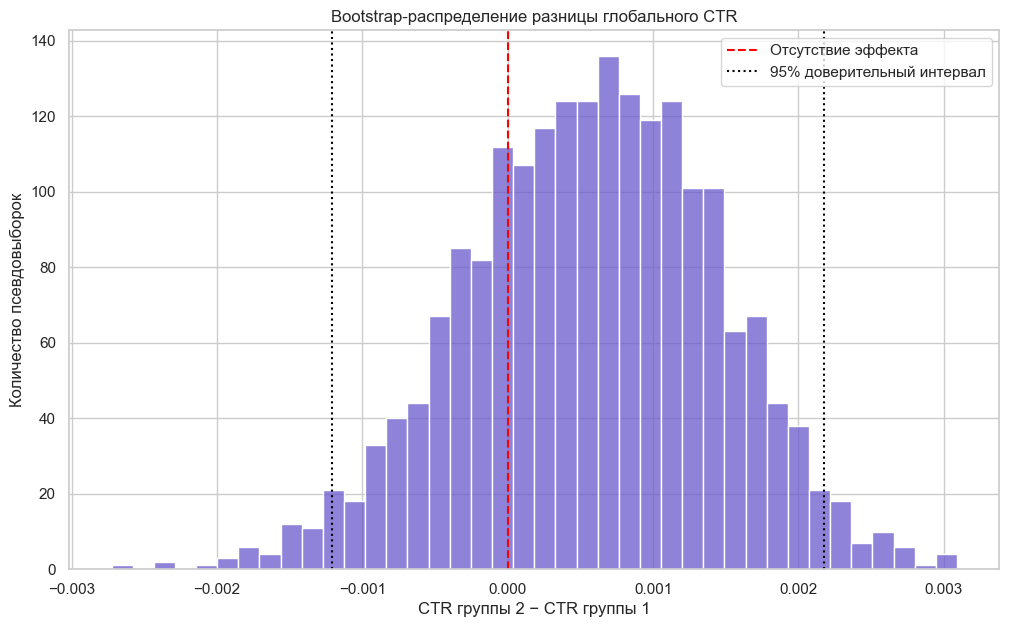

In [10]:
plt.figure(figsize=(12, 7))

sns.histplot(
    bootstrap_difference,
    bins=40,
    color="slateblue",
)
plt.axvline(
    0,
    color="red",
    linestyle="--",
    label="Отсутствие эффекта",
)
plt.axvline(
    bootstrap_ci[0],
    color="black",
    linestyle=":",
    label="95% доверительный интервал",
)
plt.axvline(
    bootstrap_ci[1],
    color="black",
    linestyle=":",
)
plt.title("Bootstrap-распределение разницы глобального CTR")
plt.xlabel("CTR группы 2 − CTR группы 1")
plt.ylabel("Количество псевдовыборок")
plt.legend()
plt.show()

95% доверительный интервал разницы включает ноль. Bootstrap также не подтверждает улучшение глобального CTR.

### 8. Бакетное преобразование

In [11]:
bucket_query = '''
SELECT
    exp_group,
    bucket,
    sum(likes) / sum(views) AS bucket_ctr,
    quantileExact(0.9)(ctr) AS ctr9
FROM
(
    SELECT
        exp_group,
        xxHash64(user_id) % 50 AS bucket,
        user_id,
        sum(action = 'like') AS likes,
        sum(action = 'view') AS views,
        likes / views AS ctr
    FROM simulator_20260620.feed_actions
    WHERE toDate(time) BETWEEN '2026-06-26' AND '2026-07-02'
      AND exp_group IN (1, 2)
    GROUP BY
        exp_group,
        bucket,
        user_id
)
GROUP BY
    exp_group,
    bucket
'''

bucket_df = pandahouse.read_clickhouse(
    bucket_query,
    connection=connection,
)

bucket_df.groupby("exp_group").agg(
    buckets=("bucket", "nunique"),
    mean_bucket_ctr=("bucket_ctr", "mean"),
    median_bucket_ctr=("bucket_ctr", "median"),
)

,buckets,mean_bucket_ctr,median_bucket_ctr
exp_group,,,
1,50,0.208731,0.208456
2,50,0.209452,0.208487


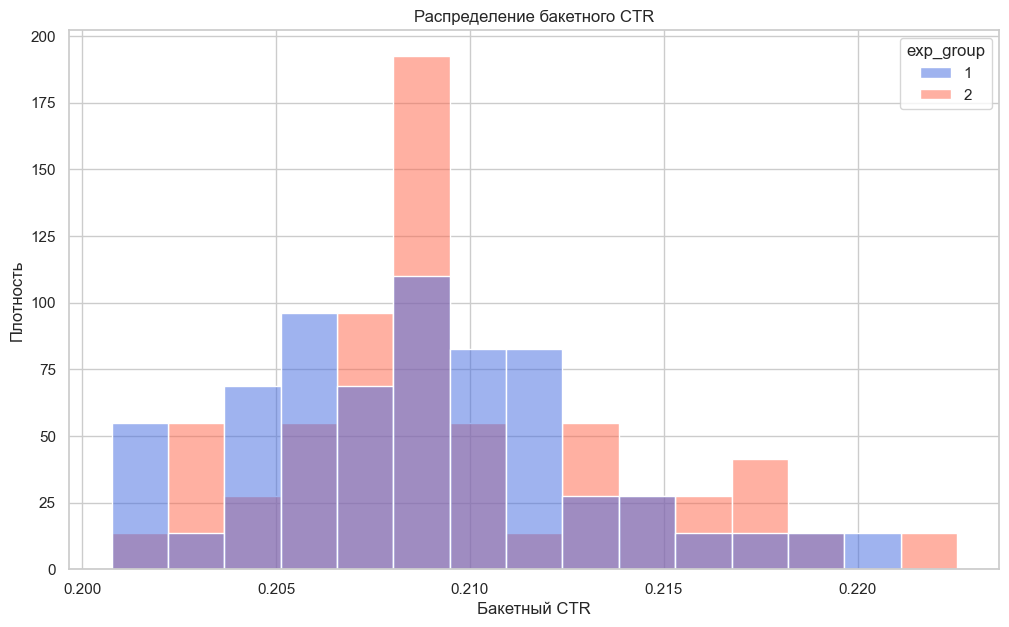

In [12]:
plt.figure(figsize=(12, 7))

sns.histplot(
    data=bucket_df,
    x="bucket_ctr",
    hue="exp_group",
    bins=15,
    stat="density",
    common_norm=False,
    palette={1: "royalblue", 2: "tomato"},
    alpha=0.5,
)
plt.title("Распределение бакетного CTR")
plt.xlabel("Бакетный CTR")
plt.ylabel("Плотность")
plt.show()

In [13]:
bucket_ctr_group_1 = bucket_df.loc[
    bucket_df["exp_group"] == 1, "bucket_ctr"
]
bucket_ctr_group_2 = bucket_df.loc[
    bucket_df["exp_group"] == 2, "bucket_ctr"
]

bucket_ttest = stats.ttest_ind(
    bucket_ctr_group_1,
    bucket_ctr_group_2,
    equal_var=False,
)

bucket_mannwhitney = stats.mannwhitneyu(
    bucket_ctr_group_1,
    bucket_ctr_group_2,
    alternative="two-sided",
)

pd.DataFrame({
    "test": [
        "Welch t-test бакетного CTR",
        "Mann–Whitney U бакетного CTR",
    ],
    "statistic": [
        bucket_ttest.statistic,
        bucket_mannwhitney.statistic,
    ],
    "p_value": [
        bucket_ttest.pvalue,
        bucket_mannwhitney.pvalue,
    ],
})

,test,statistic,p_value
0,Welch t-test бакетного CTR,-0.793497,0.429408
1,Mann–Whitney U бакетного CTR,1137.000000,0.438012


### 9. Сводная таблица тестов

In [14]:
test_results = pd.DataFrame({
    "method": [
        "Welch t-test пользовательского CTR",
        "Mann–Whitney U пользовательского CTR",
        "Welch t-test сглаженного CTR",
        "Пуассоновский bootstrap",
        "Welch t-test бакетного CTR",
        "Mann–Whitney U бакетного CTR",
    ],
    "p_value": [
        raw_ttest.pvalue,
        raw_mannwhitney.pvalue,
        smoothed_ttest.pvalue,
        bootstrap_pvalue,
        bucket_ttest.pvalue,
        bucket_mannwhitney.pvalue,
    ],
})

test_results["significant_at_0.05"] = (
    test_results["p_value"] < 0.05
)
test_results

,method,p_value,significant_at_0.05
0,Welch t-test пользовательского CTR,0.752559,False
1,Mann–Whitney U пользовательского CTR,0.470811,False
2,Welch t-test сглаженного CTR,0.595518,False
3,Пуассоновский bootstrap,0.513000,False
4,Welch t-test бакетного CTR,0.429408,False
5,Mann–Whitney U бакетного CTR,0.438012,False


## Takeaways

### Почему тесты сработали именно так

Результаты всех методов согласованы. Разница глобального CTR положительная, но очень маленькая по сравнению с естественной вариативностью пользовательского поведения. Распределения пользовательского CTR практически совпадают. Сглаживание уменьшает шум от пользователей с малым числом просмотров, а бакетное преобразование стабилизирует ratio-метрику, но устойчивого эффекта всё равно не появляется.

### Возможная продуктовая ситуация

Новый алгоритм мог изменить порядок постов, но фактически показывать контент примерно того же качества. Другой вариант — часть пользователей тестовой группы почти не столкнулась с новой выдачей, поэтому воздействие оказалось слабым. Также возможно, что улучшение офлайн-метрик рекомендательной модели не перешло в пользовательские лайки.

### Рекомендация

Не раскатывать алгоритм на всех пользователей. Статистических доказательств увеличения CTR нет, а наблюдаемое изменение слишком мало и совместимо со случайностью.

Перед следующим экспериментом:

1. проверить корректность назначения групп и логирования;
2. проверить долю пользователей с реальным контактом с новым алгоритмом;
3. посмотреть guardrail-метрики: просмотры, активность, retention;
4. заранее определить MDE и рассчитать размер выборки;
5. при необходимости повторить эксперимент.